In [1]:
import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from model.classifier import Classifier, MyProgressBar

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
torch.set_float32_matmul_precision('high')

In [3]:
from utils.transform_sequence import TransformSequence
from utils.transforms.apply import grid_resample
from utils.affine_transforms import AffineTransformation2D

transformations = [AffineTransformation2D.ROTATION.value]
domains = [(-torch.pi,torch.pi),]
n_samples = 17

transform_seq= TransformSequence(transformations, domains, neighbour_hood_size =0.25,application_method=grid_resample,device=device,reflect=True,use_individual_param_correction=False)

In [4]:
from its.transform import multi_transform
from dataset.mnist_no_pil import NoPILMNIST, NoPILFashionMNIST, AffineTransformDataset

dataset = 'mnist' # or 'fmnist'
batch_size = 128
#divide by 255 transform


if dataset == 'mnist':
    # essentially excluding either 6 or 9 as these would cause degenerations under 180 degree rotation
    dataset_train = NoPILMNIST("../experiment_files/data",train=True,download=True)
    n_classes = 10
    dataset_val_test = NoPILMNIST("../experiment_files/data",train=False,download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = #fix this, use val from train as this is what is usually expected.
elif dataset == 'fmnist':
    dataset_train = NoPILFashionMNIST("../experiment_files/data",train=True,download=True)
    n_classes = 10
    dataset_val_test = NoPILFashionMNIST("../experiment_files/data",train=False,download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = #fix this, use val from train as this is what is usually expected.




def transform(batch_size):
    n = torch.randint(0, n_samples, (batch_size, len(transformations)), device="cpu")
    x_test = torch.zeros(batch_size, 1, 28, 28, device="cpu")
    _, _, T = multi_transform(x_test, transformations, n, n_samples=n_samples, domain=domains)
    return T


dataset_test = AffineTransformDataset(dataset_test_pre,transform,return_transformation=False,batch_size=batch_size)


# Create transformed datasets for both training and testing
dataset_train_transformed = AffineTransformDataset(dataset_train, transform, return_transformation=False, batch_size=batch_size)


In [5]:
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True, num_workers=4, persistent_workers=True)
val_loader = torch.utils.data.DataLoader(dataset_val, batch_size=batch_size, shuffle=False, num_workers=4, persistent_workers=True)
test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False, num_workers=4, persistent_workers=True)

# Create data loader for transformed training data
train_transformed_loader = torch.utils.data.DataLoader(dataset_train_transformed, batch_size=batch_size, shuffle=True, num_workers=4, persistent_workers=True)


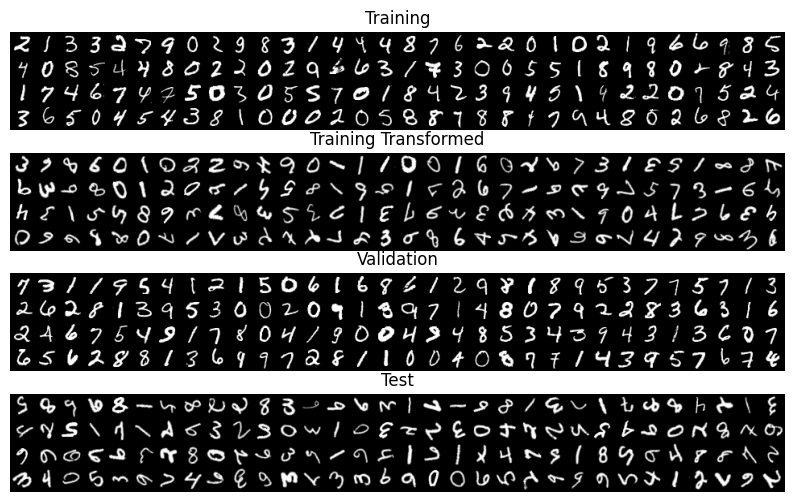

In [6]:
#test images
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(10, 6))

axs[0].imshow(torchvision.utils.make_grid(next(iter(train_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[1].imshow(torchvision.utils.make_grid(next(iter(train_transformed_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[2].imshow(torchvision.utils.make_grid(next(iter(val_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[3].imshow(torchvision.utils.make_grid(next(iter(test_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[0].set_title('Training')
axs[1].set_title('Training Transformed')
axs[2].set_title('Validation')
axs[3].set_title('Test')

for ax in axs.flat:
    ax.axis('off')

In [7]:
import pytorch_lightning as pl
import os

model_path = f'../model/{dataset}_rot_only.pth'

model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 32x14x14
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)


# Check if model is already trained
if os.path.exists(model_path):
    print(f"Loading model from {model_path}")
    model.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")
    lightning_model = Classifier(model, optimizer_class =  torch.optim.AdamW, optimizer_params = {"lr": 1e-3})
    progress_bar = MyProgressBar()
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=10,
        precision="16-mixed",
        callbacks=[progress_bar],
    )
    # Train the model
    trainer.fit(lightning_model, train_loader,val_loader)
    # Test the model
    #trainer.test(lightning_model, test_loader)
    # Save model
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")


Loading model from ../model/mnist_rot_only.pth


In [8]:

from equiadapt.images.canonicalization.continuous_group import SteerableImageCanonicalization
from equiadapt.images.canonicalization_networks import ESCNNSteerableNetwork

In [9]:

from omegaconf import OmegaConf
canonicalization_network = ESCNNSteerableNetwork(in_shape=(1, 28, 28), out_channels=32, kernel_size=7)
dict_config = OmegaConf.create({
    "beta": 1.0,
    "maximum_frequency": 3,
})
canonicalizer = SteerableImageCanonicalization(canonicalization_network,
dict_config,(1, 28, 28)).cuda()

In [10]:
model.cuda()

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=3136, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)

In [11]:
def test():
    avg_acc = 0
    for batch in tqdm.tqdm(test_loader):
        x, y = batch
        x = x.cuda()
        x_canonicalized = canonicalizer(x)
        logits = model(x_canonicalized)
        output = logits.argmax(dim=-1)
        loss = nn.CrossEntropyLoss()(logits, y.cuda())
        acc = output.eq(y.cuda()).sum().item()
        avg_acc += acc


    avg_acc /= len(dataset_test)
    print(f'Accuracy on the test set after canonicalization: {avg_acc}.')
import tqdm
for i in range(30):
    opt = torch.optim.AdamW(canonicalization_network.parameters(), lr=1e-3)
    for batch in tqdm.tqdm(train_transformed_loader):
        opt.zero_grad()
        x, y = batch
        x = x.cuda()
        x_canonicalized = canonicalizer(x)
        logits = model(x_canonicalized)
        loss = nn.CrossEntropyLoss()(logits, y.cuda())
        loss += canonicalizer.get_prior_regularization_loss()
        loss.backward()
        opt.step()
    test()



100%|██████████| 40/40 [00:00<00:00, 77.97it/s]


Accuracy on the test set after canonicalization: 0.7952.


100%|██████████| 40/40 [00:00<00:00, 100.28it/s]


Accuracy on the test set after canonicalization: 0.8044.


100%|██████████| 40/40 [00:00<00:00, 90.03it/s]


...

Accuracy on the test set after canonicalization: 0.864.


100%|██████████| 40/40 [00:00<00:00, 52.93it/s]


Accuracy on the test set after canonicalization: 0.866.


100%|██████████| 40/40 [00:00<00:00, 56.40it/s]

Accuracy on the test set after canonicalization: 0.8724.


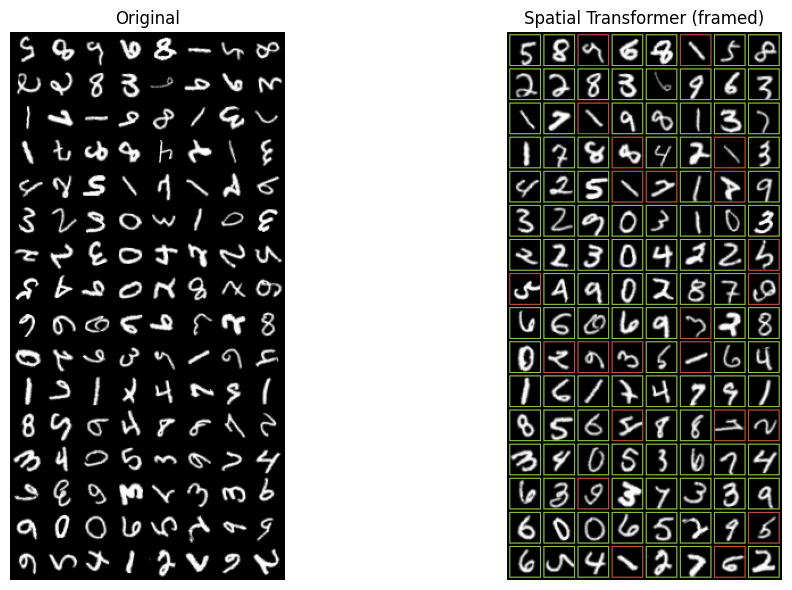

In [12]:
#validate on testset
#plot some samples
with torch.no_grad():
    # 1. Load a batch
    data, target = next(iter(test_loader))
    data, target = data.cuda(), target.cuda()

    # 2. Apply spatial transformer
    transformed = canonicalizer(data)

    # 3. Get predictions and correctness mask
    preds = model(transformed).argmax(dim=1)
    correct = preds.eq(target)

    # 4. Define frame colors
    green = torch.tensor((143, 194, 62))[:, None] / 255.
    red = torch.tensor((194, 80, 62))[:, None] / 255.

    # 5. Draw colored frames on transformed images
    imgs = transformed.repeat(1, 3, 1, 1)  # ensure 3 channels
    for img, is_correct in zip(imgs, correct):
        color = green if is_correct else red
        img[:, 0, :] = color
        img[:, -1, :] = color
        img[:, :, 0] = color
        img[:, :, -1] = color

    # 6. Plot original vs. framed outputs
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(torchvision.utils.make_grid(data.cpu(), nrow=8).permute(1, 2, 0), cmap='gray')
    axs[0].set_title('Original')
    axs[0].axis('off')

    axs[1].imshow(torchvision.utils.make_grid(imgs.cpu(), nrow=8).permute(1, 2, 0))
    axs[1].set_title('Spatial Transformer (framed)')
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

In [13]:
#calibrate the model
#from confidence.calibration import TemperatureCalibrationModule
#if model is not temperature calibrated
#if isinstance(model, TemperatureCalibrationModule):
    #model = model.model
#model = TemperatureCalibrationModule(model,per_logit=True).cuda()
#model.fit(test_loader)


In [14]:
model.cuda()


Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=3136, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)

In [15]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in val_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_val)
    print(f'Mean accuracy on the val set: {test_acc}.')

Mean accuracy on the val set: 0.9872.


In [16]:
from confidence.utils import ModelInputWrapper

#use model wrapper to extract the embeddings
dual_ouput_model = ModelInputWrapper(model,'9',flatten=True)

In [17]:
#extract embeddings and fit NNDistanceConfidence()
embeddings = []
classes = []
for batch in train_loader:
    emb, _ = dual_ouput_model(batch[0].cuda())
    embeddings.append(emb.detach().cpu().numpy())
    classes.append(batch[1].detach().cpu().numpy())

embeddings = np.vstack(embeddings)
classes = np.hstack(classes)

#randomly sample 5000 ones
if embeddings.shape[0] > 5000:
    indices = np.random.choice(embeddings.shape[0], 5000, replace=False)
    embeddings = embeddings[indices]
    classes = classes[indices]

